# Task 1 — Exploratory Data Analysis: Brent Crude Oil Prices

Birhan Energies | Change Point Analysis Project

This notebook covers:
1. Data loading & cleaning
2. Trend analysis
3. Stationarity testing (ADF, KPSS)
4. Volatility analysis
5. Initial EDA findings summary


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_raw_prices, load_events
from eda import add_returns, summarize_stationarity

plt.rcParams['figure.figsize'] = (11, 4)

## 1. Load & clean data

In [2]:
df = load_raw_prices('../data/raw/BrentOilPrices.csv')
print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Rows: 9011
Date range: 1987-05-20 to 2022-11-14


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


## 2. Trend analysis

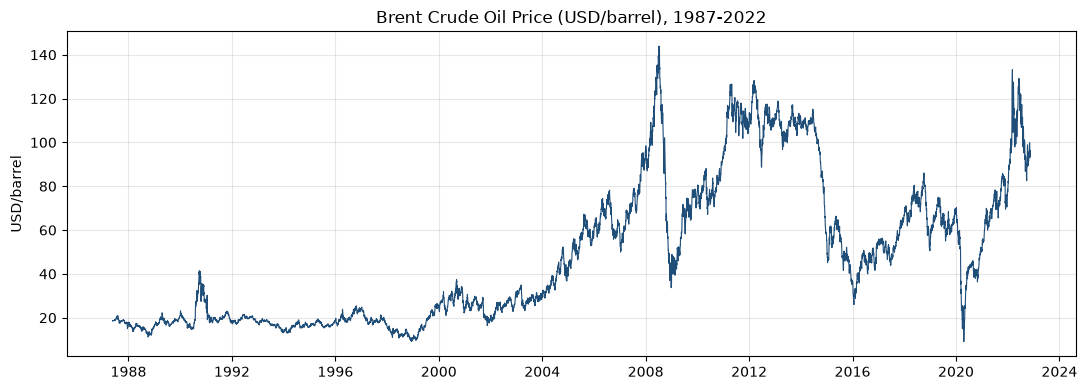

In [4]:
fig, ax = plt.subplots()
ax.plot(df['Date'], df['Price'], linewidth=0.8, color='#1f4e79')
ax.set_title('Brent Crude Oil Price (USD/barrel), 1987-2022')
ax.set_ylabel('USD/barrel')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The price level shows a strong long-run upward drift punctuated by several large
regime shifts (2008 spike & crash, 2011-14 plateau above $100, 2014-16 collapse,
2020 COVID crash, 2021-22 recovery). This non-stationary, regime-driven behavior
is exactly what change point models are designed to detect.

## 3. Stationarity testing

In [5]:
df = add_returns(df)
summarize_stationarity(df)

c:\Users\user\Downloads\week-10\brent-oil-change-point-analysis\notebooks\../src\eda.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, *_ = kpss(series.dropna(), regression=regression, nlags="auto")
c:\Users\user\Downloads\week-10\brent-oil-change-point-analysis\notebooks\../src\eda.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, *_ = kpss(series.dropna(), regression=regression, nlags="auto")


,series,adf_statistic,adf_p_value,kpss_statistic,kpss_p_value
0,Price (level),-1.993856,2.892735e-01,9.558800,0.01
1,LogReturn,-16.427113,2.498580e-29,0.034274,0.10


**Findings:**
- ADF on price level: fails to reject the unit-root null → non-stationary
- KPSS on price level: rejects stationarity null → confirms non-stationary
- ADF on log returns: strongly rejects unit-root null → log returns are stationary

**Implication:** the change point model should operate on log returns (or log
price with a trend term), not on the raw price level.

## 4. Volatility analysis

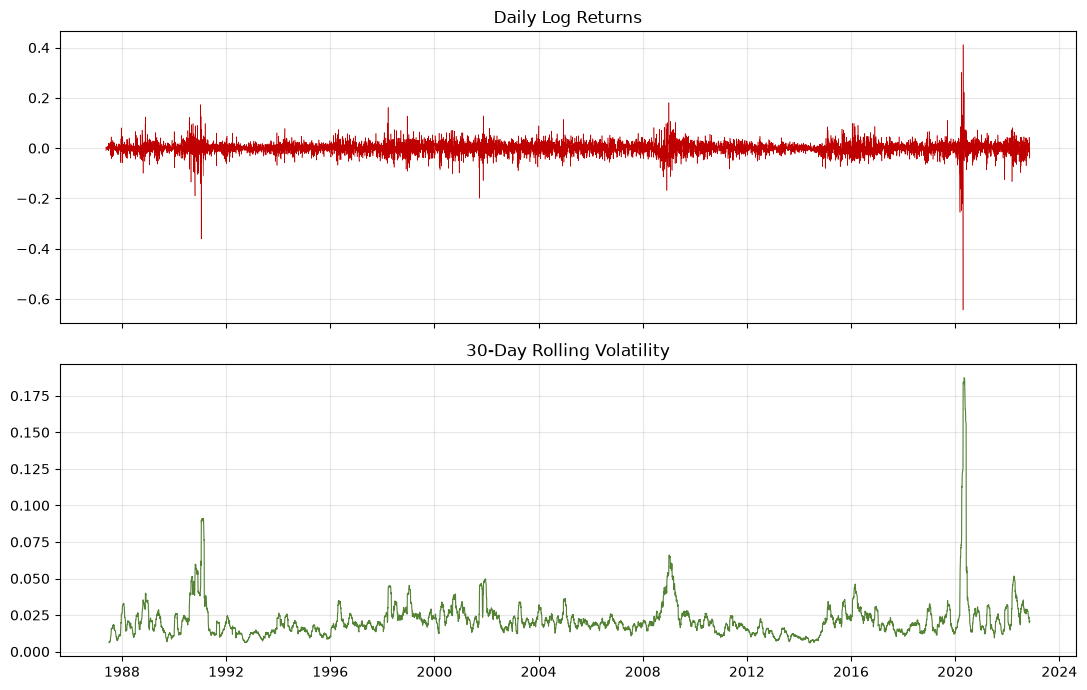

count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: LogReturn, dtype: float64
Skew: -1.744406286069927
Excess kurtosis: 65.90472347706876


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df['Date'], df['LogReturn'], linewidth=0.4, color='#c00000')
axes[0].set_title('Daily Log Returns')
axes[0].grid(alpha=0.3)

axes[1].plot(df['Date'], df['RollingVol30'], linewidth=0.8, color='#548235')
axes[1].set_title('30-Day Rolling Volatility')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(df['LogReturn'].describe())
print('Skew:', df['LogReturn'].skew())
print('Excess kurtosis:', df['LogReturn'].kurtosis())

**Findings:** Log returns average close to zero but are heavily fat-tailed
(excess kurtosis ~66) with pronounced volatility clustering visible around
2008-09, 2014-16, and 2020. Large moves cluster in time — regime changes are
as much about shifts in variance as shifts in mean.

## 5. Load compiled event dataset

In [7]:
events = load_events('../data/processed/key_events.csv')
events[['start_date', 'event_name', 'category', 'expected_direction']]

,start_date,event_name,category,expected_direction
0,1990-08-02,Gulf War (Iraqi invasion of Kuwait),Conflict,Increase
1,1997-07-02,Asian Financial Crisis,Economic Shock,Decrease
2,2001-09-11,September 11 attacks,Geopolitical,Decrease
3,2003-03-20,US invasion of Iraq,Conflict,Increase
4,2008-07-11,Brent price peaks near record high,Market Peak,Increase
5,2008-09-15,Global Financial Crisis (Lehman collapse),Economic Shock,Decrease
6,2010-12-18,Arab Spring,Geopolitical,Increase
7,2011-02-15,Libyan Civil War,Conflict,Increase
8,2014-06-01,2014 Oil Price Collapse (Shale boom & OPEC ina...,OPEC Policy / Supply Glut,Decrease
9,2016-11-30,OPEC+ Agreement (first coordinated cuts with R...,OPEC Policy,Increase


## Summary of Initial EDA Findings

1. **Trend:** Brent prices are non-stationary in level, with multiple distinct
   multi-year regimes rather than a single stable trend.
2. **Stationarity:** Confirmed via ADF/KPSS — price level is non-stationary,
   log returns are stationary. Modeling should use log returns and/or log price.
3. **Volatility:** Strong volatility clustering and fat tails (excess kurtosis
   ~66); variance itself shifts across regimes, so the change point model
   should allow for shifts in volatility, not just mean.
4. **Events:** 17 major events compiled (conflicts, OPEC/OPEC+ decisions,
   sanctions, economic shocks) spanning 1990-2022, to be cross-referenced
   against detected change points in Task 2.